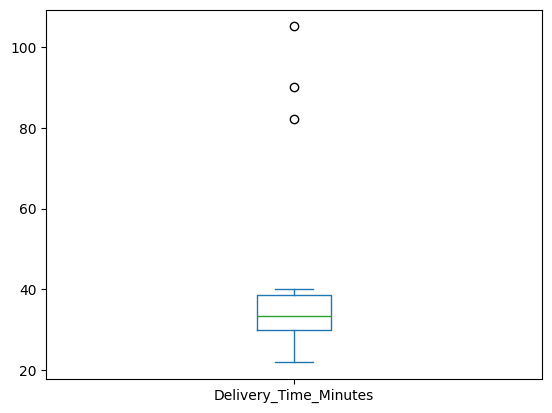

Mean: 42.05555555555556
Median: 33.5
Mode: 30
Variance: 573.5849673202614
Standard Deviation: 23.949633970486094


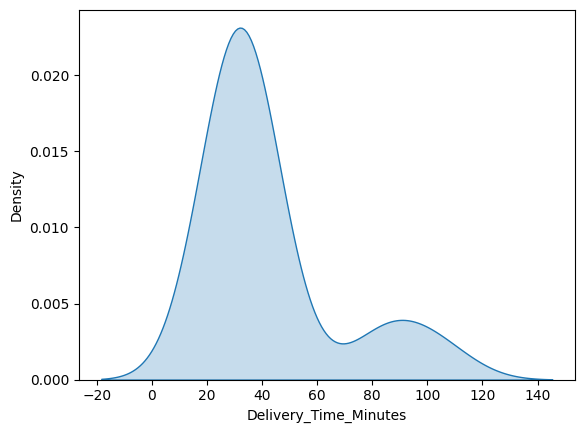

Distribution                  : Right-skewed
The distribution is RIGHT-SKEWED because the mean is greater than the median.


In [ ]:
## ------------------------------------ ##
## SECTION-B ##
## ------------------------------------ ##

# Task:-1 =>Define a hardcoded list of at least 15 delivery time values (in minutes) that
# includes realistic values between 20–40 minutes and at least 3 outliers above 75 minutes.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("/content/sample_data/delivery_time_statistical_profiler_data.csv")
df['Delivery_Time_Minutes'].plot(kind='box')
plt.show()
#  as we can see it has outliers above 70 min.


# Calculate and print the mean, median, mode, variance, and standard deviation
#  using Python's built-in statistics module.
import statistics
mean = statistics.mean(df['Delivery_Time_Minutes'])
median = statistics.median(df['Delivery_Time_Minutes'])
Mode = statistics.mode(df['Delivery_Time_Minutes'])
Variance = statistics.variance(df['Delivery_Time_Minutes'])
Standard_Deviation = statistics.stdev(df['Delivery_Time_Minutes'])
print(f"Mean: {mean}")
print(f"Median: {median}")
print(f"Mode: {Mode}")
print(f"Variance: {Variance}")
print(f"Standard Deviation: {Standard_Deviation}")

# Determine whether the distribution is left-skewed, right-skewed, or approximately
#  symmetrical by comparing the mean and median, and print a clearly worded conclusion.
sns.kdeplot(data=df, x="Delivery_Time_Minutes", fill=True)
plt.show()

if mean > median:
    skew = "Right-skewed"
    conclusion = (
        "The distribution is RIGHT-SKEWED because the mean "
        "is greater than the median."
    )
elif mean < median:
    skew = "Left-skewed"
    conclusion = (
        "The distribution is LEFT-SKEWED because the mean "
        "is less than the median."
    )
else:
    skew = "Approximately symmetrical"
    conclusion = (
        "The distribution is APPROXIMATELY SYMMETRICAL because "
        "the mean and median are approximately equal."
    )
print(f"{'Distribution':<30}: {skew}")
print(f"{'The distribution is RIGHT-SKEWED because the mean is greater than the median.'}")

In [ ]:
# Task 2: Order Dataset Preprocessor
# Create a pandas DataFrame with at least 12 rows containing columns: order_id (int),
# restaurant_rating (float with at least 2 NaN values), payment_method
# (Cash / Card / Wallet), cuisine_type (Indian / Chinese / Italian / Fast Food), and order_value (float).
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("/content/sample_data/order_dataset.csv")
print(df)

# Fill missing restaurant_rating values with the column mean and verify no NaN
# values remain using isnull().sum().
df.isnull().sum()
df['restaurant_rating'].fillna(df['restaurant_rating'].mean(), inplace=True)
df.isnull().sum()


# Apply one-hot encoding to both payment_method and cuisine_type using pd.get_dummies()
# and drop the original categorical columns from the DataFrame.
df = pd.get_dummies(
    df,
    columns=['payment_method', 'cuisine_type'],
    dtype=int
)


# Apply MinMaxScaler from sklearn.preprocessing to the restaurant_rating and order_value
#  columns only, then print the final preprocessed DataFrame.
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df[['restaurant_rating', 'order_value']] = scaler.fit_transform(df[['restaurant_rating', 'order_value']])
print(df)
df


    order_id  restaurant_rating payment_method cuisine_type  order_value
0       1001                4.5           Cash       Indian        350.0
1       1002                4.0           Card      Chinese        520.0
2       1003                NaN         Wallet      Italian        275.0
3       1004                3.5           Card    Fast Food        450.0
4       1005                4.8           Cash       Indian        680.0
5       1006                NaN         Wallet      Chinese        320.0
6       1007                4.2           Card      Italian        590.0
7       1008                3.9           Cash    Fast Food        410.0
8       1009                4.6         Wallet       Indian        720.0
9       1010                3.8           Card      Chinese        260.0
10      1011                4.1           Cash      Italian        500.0
11      1012                4.7         Wallet    Fast Food        630.0
    order_id  restaurant_rating  order_value  payme

/tmp/ipykernel_1110/2920468701.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['restaurant_rating'].fillna(df['restaurant_rating'].mean(), inplace=True)


,order_id,restaurant_rating,order_value,payment_method_Card,payment_method_Cash,payment_method_Wallet,cuisine_type_Chinese,cuisine_type_Fast Food,cuisine_type_Indian,cuisine_type_Italian
0,1001,0.769231,0.195652,0,1,0,0,0,1,0
1,1002,0.384615,0.565217,1,0,0,1,0,0,0
2,1003,0.546154,0.032609,0,0,1,0,0,0,1
3,1004,0.000000,0.413043,1,0,0,0,1,0,0
4,1005,1.000000,0.913043,0,1,0,0,0,1,0
5,1006,0.546154,0.130435,0,0,1,1,0,0,0
6,1007,0.538462,0.717391,1,0,0,0,0,0,1
7,1008,0.307692,0.326087,0,1,0,0,1,0,0
8,1009,0.846154,1.000000,0,0,1,0,0,1,0
9,1010,0.230769,0.000000,1,0,0,1,0,0,0


In [ ]:
# Task 3: Order Cancellation Classifier with Evaluation
# Create or use a sample dataset of at least 120 records with features: order_value (float),
# delivery_distance_km (float), hour_of_day (int 0–23), and restaurant_rating (float),
# with a target column cancelled containing 1 (cancelled) and 0 (not cancelled) where approximately 20–25% are cancelled.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
df = pd.read_csv("/content/sample_data/order_cancellation_classifier_dataset.csv")

# Split the data into 80% training and 20% test sets using train_test_split with
# stratify=cancelled and random_state=42.
x = df.drop('cancelled', axis=1)
y = df['cancelled']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42,stratify=y)

# Train a RandomForestClassifier with random_state=42, generate predictions on the test set,
# and print the full classification_report showing precision, recall, and F1-score for both classes.
# Compute and print the confusion matrix as a labelled 2×2 table identifying TP, TN, FP, and FN values explicitly in the output.
model = RandomForestClassifier(random_state=42)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
from sklearn.metrics import classification_report, confusion_matrix
print(y_pred)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


[0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0 0 0 0 1 0 0 0 1]
              precision    recall  f1-score   support

           0       0.88      0.96      0.92        23
           1       0.80      0.57      0.67         7

    accuracy                           0.87        30
   macro avg       0.84      0.76      0.79        30
weighted avg       0.86      0.87      0.86        30

[[22  1]
 [ 3  4]]


Inertia for k=2: 216.19119463022372
Inertia for k=3: 136.65902243253686
Inertia for k=4: 109.02008822683035
Inertia for k=5: 92.28858416016683
Inertia for k=6: 78.92354395813034
Inertia for k=7: 67.97544101668798
Inertia for k=8: 60.25675647763871
Inertia for k=9: 56.76427216881205


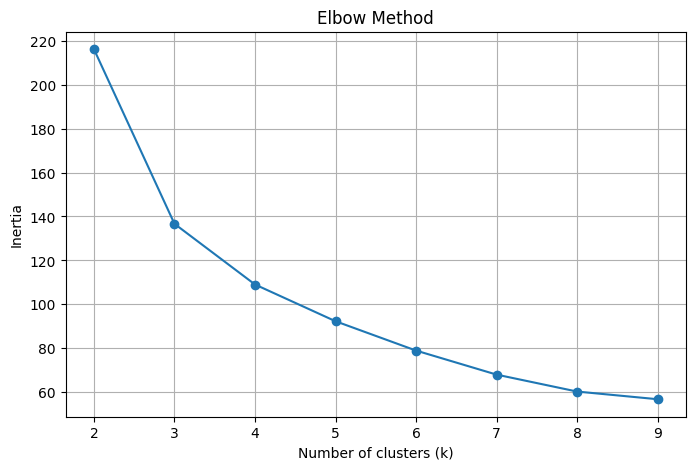

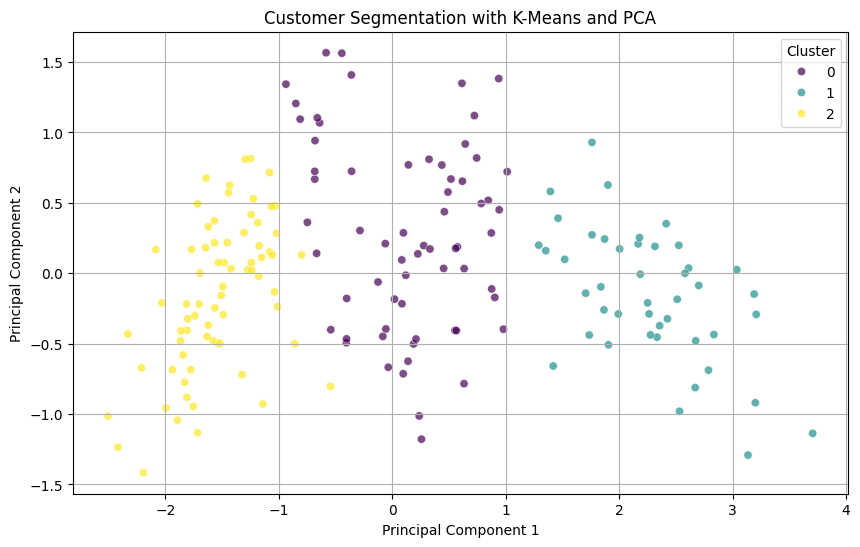

In [56]:
# Task 4: Customer Segmentation with K-Means and PCA Visualisation
# Create or load a dataset of at least 150 customers with three features: monthly_orders (int),
# avg_order_value (float), and avg_delivery_rating (float 1.0–5.0). Apply StandardScaler to all three features before clustering.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
df = pd.read_csv("/content/sample_data/food_delivery_customer_segmentation.csv")
x = df[['monthly_orders', 'avg_order_value', 'avg_delivery_rating']]
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)


# Run K-Means for k values from 2 to 9, record the inertia for each k, and plot the
#  Elbow Method graph with k on the x-axis, inertia on the y-axis, and clear axis
#   labels and a title.
inertias = []

for k in range(2, 10):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(x_scaled)
    inertias.append(kmeans.inertia_)

    print(f"Inertia for k={k}: {kmeans.inertia_}")


# Plot AFTER the loop
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 10),
    inertias,
    marker='o'
)

plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')

plt.xticks(range(2, 10))
plt.grid(True)

plt.show()


# Train a final K-Means model using the optimal k identified from the elbow graph and
# assign cluster labels to all customer records. Apply PCA to reduce the scaled data
# to 2 components, then produce a scatter plot with each cluster in a distinct colour,
#  a legend identifying cluster numbers, and axis labels showing PC1 and PC2.
k_model = kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)
k_model.fit(x_scaled)
df['cluster'] = k_model.labels_
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_scaled)
df['PC1'] = x_pca[:, 0]
df['PC2'] = x_pca[:, 1]
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='PC1',
    y='PC2',
    hue='cluster',
    palette='viridis',
    alpha=0.7
)
plt.title('Customer Segmentation with K-Means and PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()